In [286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.constants as const
import glob
print(const.k_B)
from set_rcParams import set_rcParams
set_rcParams()

  Name   = Boltzmann constant
  Value  = 1.380649e-23
  Uncertainty  = 0.0
  Unit  = J / K
  Reference = CODATA 2018


In [287]:

def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * const.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * const.k_B.value * T))

alpha_range = np.linspace(0, 6000, 200)
beta_range = np.linspace(0, 2500, 200)
m = 6.6e-27
T_a = 1000
T_b = 100

alpha_actual_dist = f_M(alpha_range, T_a, m)
beta_actual_dist = f_M(beta_range, T_b, m)

In [288]:
# alpha = data[data["species"] == 0]
# beta = data[data["species"] == 1]

# def speed_from_df(df):
#   return  np.sqrt(df["v_x"]**2 +  df["v_y"]**2 +  df["v_z"]**2)

In [289]:

# alpha_speed = speed_from_df(alpha)

# beta_speed = speed_from_df(beta)

# plt.figure()
# plt.hist(alpha_speed, bins=30, density=True)
# plt.plot(alpha_range, alpha_actual_dist, '--')
# plt.show()



# plt.figure()
# plt.hist(beta_speed, bins=30, density=True)
# plt.plot(beta_range, beta_actual_dist, '--')
# plt.show()

In [290]:
# def temp_from_mean_speed(speed_array, mass : float = m) -> float:
#   return (1/3) * mass * (speed_array**2).mean() / const.k_B.value

In [291]:
# T_alpha = temp_from_mean_speed(alpha_speed)
# print(T_alpha)

# T_beta = temp_from_mean_speed(beta_speed)
# print(T_beta)

In [ ]:
# files = sorted(glob.glob("testing_out_*.csv"))[1:]

# alpha_T = []
# beta_T = []
# time = []
# for f in files:
#   data = pd.read_csv(f)

#   alpha = data[data["species"] == 0]
#   beta = data[data["species"] == 1]
#   time.append(data["t_vel"][0])

#   alpha_T.append(temp_from_mean_speed(speed_from_df(alpha)))
#   beta_T.append(temp_from_mean_speed(speed_from_df(beta)))

runs = 10
T_alphas = []
T_betas = []
for i in range(10):
  data = pd.read_csv(f"run_{i:d}.csv")
  T_alphas.append(data["T_alpha"][1:].to_numpy())
  T_betas.append(data["T_beta"][1:].to_numpy())

T_alphas = np.array(T_alphas)
T_betas = np.array(T_betas)
time = data["time"][1:].to_numpy()

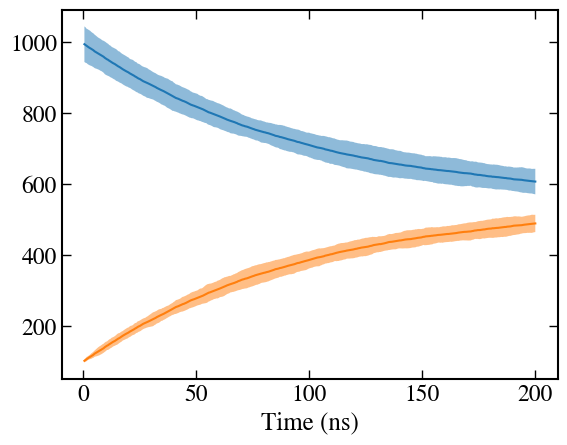

In [321]:
mean_T_alpha = T_alphas.mean(axis=0)
std_T_alpha = T_alphas.std(axis=0)
mean_T_beta = T_betas.mean(axis=0)
std_T_beta = T_betas.std(axis=0)

plt.figure()
plt.fill_between(time * 1e9, mean_T_alpha - 2 * std_T_alpha, mean_T_alpha + 2 * std_T_alpha, alpha=0.5)
plt.fill_between(time * 1e9, mean_T_beta - 2 * std_T_beta, mean_T_beta + 2 * std_T_beta, alpha=0.5)
plt.plot(time * 1e9, mean_T_alpha)
plt.plot(time * 1e9, mean_T_beta)
plt.xlabel("Time (ns)")
plt.show()

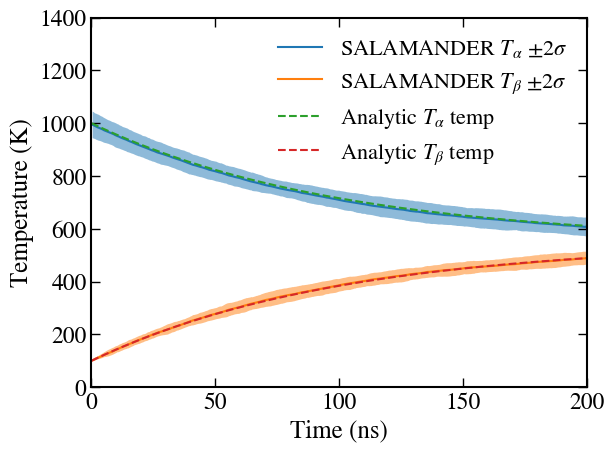

In [330]:
def calc_nu_ab(m_a, m_b, sigma_0, n):
  M = m_a + m_b
  m_ab = m_a * m_b / M
  return m_ab / (m_a + m_b) * 3 * n * sigma_0

def T_alpha(nu_ab, t):
  return 550 + 450 * np.exp(-4/3 * nu_ab * t)

def T_beta(nu_ab, t):
  return 550 - 450 * np.exp(-4/3 * nu_ab * t)

m = 6.646764e-27
m_a = m
m_b = m
sigma_0 = 1e-18
n = 1e25
nu_ab = calc_nu_ab(m_a, m_b, sigma_0, n)

t = np.arange(0, 200e-9, 0.1e-9)

plt.figure()

plt.fill_between(time * 1e9, mean_T_alpha - 2 * std_T_alpha, mean_T_alpha + 2 * std_T_alpha, alpha=0.5)
plt.fill_between(time * 1e9, mean_T_beta - 2 * std_T_beta, mean_T_beta + 2 * std_T_beta, alpha=0.5)
plt.plot(time * 1e9, mean_T_alpha, label="SALAMANDER $T_\\alpha$ $\\pm2\\sigma$")
plt.plot(time * 1e9, mean_T_beta, label="SALAMANDER $T_\\beta$ $\\pm2\\sigma$")

plt.plot(t * 1e9, T_alpha(nu_ab, t), '--', label="Analytic $T_\\alpha$ temp")
plt.plot(t * 1e9, T_beta(nu_ab, t), '--', label="Analytic $T_\\beta$ temp")
# plt.plot(time * 1e9, mean_T_alpha, '--', label="SALAMANDER $\\alpha$ temp")
# plt.plot(time * 1e9, mean_T_beta, label="SALAMANDER $\\beta$ temp")
plt.xlabel("Time (ns)")
plt.ylabel("Temperature (K)")
plt.ylim(bottom=0, top=1400)
plt.xlim(left=0, right=200)
plt.legend()
plt.show()